# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

In [ ]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [2]:
df = pd.read_csv('Mall_Customers.csv', delimiter=',')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [ ]:
# df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [7]:
fig = px.box(df, y='Annual Income (k$)', title='BoxPlot de Annual Income (k$)')
fig.show()

In [8]:
df = df.drop(columns=['CustomerID', 'Gender'])

In [9]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


Inicialmente, foram importadas as bibliotecas necessárias para o desenvolvimento do projeto, em seguida foi realizada uma análise descritiva por meio da função 'describe()', que forneceu informações estatísticas das variáveis numéricas, como média, desvio padrão, valores mínimo e máximo e quartis. Posteriormente, foi feita a verificação dos tipos de dados utilizando a função 'dtypes', com o objetivo de identificar quais variáveis eram numéricas e quais eram categóricas.

Também foi realizada a verificação da existência de valores ausentes por meio da função 'isnull().sum()'. O resultado mostrou que o conjunto de dados não possui valores nulos, tornando desnecessária a aplicação de técnicas de imputação ou remoção de registros.

Na sequência, foi construído um boxplot da variável 'Annual Income (k$)' para verificar a presença de possíveis outliers. A inspeção visual indicou a existência de valores extremos na distribuição da renda anual. Entretanto, esses valores não foram considerados outliers, pois é esperado que alguns clientes apresentem renda anual superior à dos demais. Além disso, a diferença entre o limite superior (upper fence) e o valor máximo (max) é de apenas (k$11 mil), o que não afeta significativamente os resultados da análise. Portanto, optou-se por não realizar qualquer tratamento na variável 'Annual Income (k$)'.

Por fim, foram removidas as colunas CustomerID e Gender.

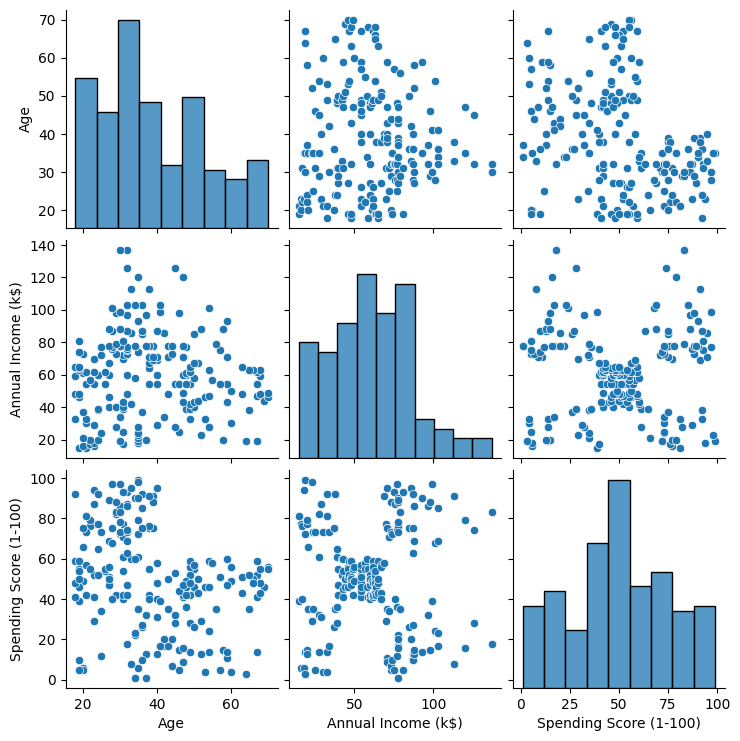

In [10]:
sns.pairplot(df)

In [10]:
fig = px.scatter(df, x='Spending Score (1-100)', y='Annual Income (k$)',
                title='Gráfico de Dispersão: Spending Score (1-100) vs. Annual Income (k$)',
                labels={'Spending Score (1-100)': 'Spending Score (1-100) Anual', 'Annual Income (k$)': 'Annual Income (k$)'})

fig.show()

Foi realizada uma análise exploratória com o objetivo de compreender melhor a distribuição das variáveis e identificar possíveis relações entre elas. Para isso, foi utilizado o gráfico PairPlot, que apresenta simultaneamente histogramas das distribuições individuais e gráficos de dispersão entre todas as combinações das variáveis 'Age', 'Annual Income (k$)' e 'Spending Score (1-100)'.

A análise dos histogramas mostrou que as três variáveis apresentam distribuições distintas. A variável 'Age' possui maior concentração de clientes entre aproximadamente 20 e 40 anos, enquanto a 'Annual Income (k$)' concentra a maior parte dos clientes em faixas intermediárias de renda. Já a variável 'Spending Score (1-100)' apresenta uma distribuição relativamente ampla, indicando diferentes perfis de consumo entre os clientes.

Os gráficos de dispersão permitiram observar a relação entre as variáveis. Entre 'Age' e 'Annual Income (k$)' não foi identificada uma correlação linear evidente, sugerindo que clientes de diferentes idades podem possuir rendas semelhantes. Da mesma forma, a relação entre 'Age' e 'Spending Score (1-100)' indica que clientes mais jovens tendem a apresentar uma maior diversidade de comportamentos de consumo, enquanto clientes mais velhos concentram-se, em geral, em faixas intermediárias de pontuação de gastos.

A inspeção visual do gráfico de dispersão entre as variáveis 'Annual Income (k$)' e 'Spending Score (1-100)' sugere a existência de aproximadamente cinco agrupamentos de clientes.

In [11]:
df_padronizado = df.copy()

In [12]:
padronizar = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
sc = StandardScaler()
df_padronizado[padronizar] = sc.fit_transform(df[padronizar])

In [13]:
df_padronizado

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


Após a aplicação do StandardScaler, o conjunto de dados passou a conter apenas valores padronizados, apresentando média próxima de zero e desvio padrão igual a um para cada variável, tornando a base adequada para a aplicação do algoritmo de clusterização.

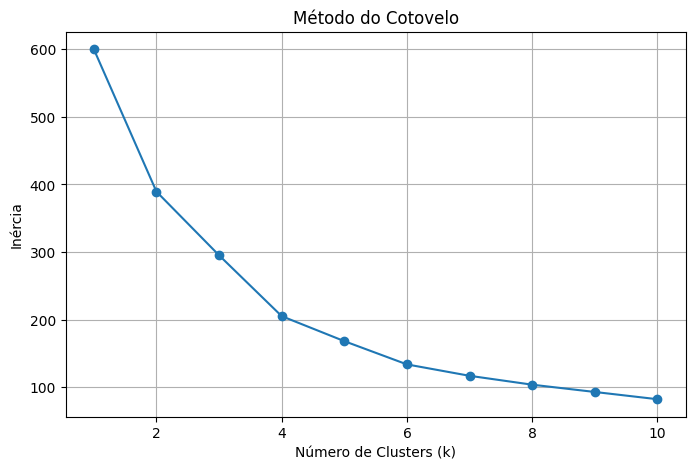

In [14]:
inercia = []

for k in range(1, 11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(df_padronizado)
    inercia.append(modelo.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inercia, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.grid(True)
plt.show()

Para definir a quantidade de clusters utilizada no algoritmo K-Means, foi aplicado o Método do Cotovelo (Elbow Method). Essa técnica consiste em executar o algoritmo para diferentes valores de k e calcular, para cada execução, a inércia, que representa a soma das distâncias quadráticas entre cada observação e o centroide do cluster ao qual pertence. À medida que o número de clusters aumenta, a inércia tende a diminuir; entretanto, busca-se identificar o ponto em que essa redução passa a ocorrer de forma menos acentuada, caracterizando o chamado "cotovelo" da curva.

A análise do gráfico mostrou uma redução significativa da inércia entre k = 1 e k = 5. A partir desse ponto, observa-se que a diminuição da inércia torna-se mais gradual, indicando ganhos cada vez menores com a criação de novos clusters. Dessa forma, optou-se por utilizar cinco clusters, pois esse valor representa um equilíbrio entre a qualidade da segmentação e a simplicidade do modelo, evitando tanto a formação de poucos grupos quanto a criação de clusters desnecessários.

In [15]:
kmeans = KMeans (n_clusters=5, n_init=10, random_state=42)
kmeans.fit(df_padronizado)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [16]:
centroides = kmeans.cluster_centers_
centroides

array([[ 0.5310735 , -1.2905084 , -1.23646671],
       [-0.98067852, -0.74305983,  0.46744035],
       [-0.42880597,  0.97484722,  1.21608539],
       [ 0.07333084,  0.97494509, -1.19729675],
       [ 1.20484056, -0.23577338, -0.05236781]])

In [17]:
centroides_padronizados = kmeans.cluster_centers_
centroides_originais = sc.inverse_transform(centroides_padronizados)
centroides_originais

array([[46.25      , 26.75      , 18.35      ],
       [25.18518519, 41.09259259, 62.24074074],
       [32.875     , 86.1       , 81.525     ],
       [39.87179487, 86.1025641 , 19.35897436],
       [55.63829787, 54.38297872, 48.85106383]])

In [18]:
labels = kmeans.labels_
labels

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

In [ ]:
silhouette = silhouette_score(df_padronizado, labels)
calinski = calinski_harabasz_score(df_padronizado, labels)
davies = davies_bouldin_score(df_padronizado, labels)

print(f'Silhouette Score: {silhouette:.3f}')
print(f'Calinski-Harabasz: {calinski:.2f}')
print(f'Davies-Bouldin: {davies:.3f}')

Silhouette Score: 0.417
Calinski-Harabasz: 125.10
Davies-Bouldin: 0.875


Nesta etapa foi realizada a aplicação do algoritmo K-Means para segmentar os clientes em grupos com características semelhantes. O modelo foi configurado com 5 clusters (n_clusters=5), quantidade escolhida com base na análise exploratória dos dados, especialmente na visualização do gráfico de dispersão entre as variáveis 'Annual Income (k$)' e 'Spending Score (1-100)', onde foi possível observar visualmente cinco agrupamentos de clientes.

Os centroides obtidos representam o perfil médio dos clientes pertencentes a cada grupo. Observa-se que um dos clusters reúne clientes com idade média de aproximadamente 46 anos, renda anual de $26,75 e baixo nível de gastos (18,35 pontos). Outro grupo é composto por clientes mais jovens, com idade média de 25 anos, renda de aproximadamente $41 e gastos elevados (62,24 pontos). Também foi identificado um cluster formado por clientes com renda anual elevada com $86 e alto nível de gastos (81,53 pontos). Em contraste, outro grupo apresenta renda igualmente elevada, porém com baixa pontuação de gastos (19,36 pontos), indicando clientes com alto poder aquisitivo, mas baixo consumo. Por fim, o quinto cluster reúne clientes mais velhos, com idade média de aproximadamente 56 anos, renda intermediária $54,38 e padrão de gastos moderado (48,85 pontos).

Após a definição do número de clusters, a qualidade da segmentação foi avaliada por meio de três métricas: Coeficiente de Silhouette, Índice de Calinski-Harabasz e Índice de Davies-Bouldin. O Coeficiente de Silhouette, que mede o grau de similaridade de cada observação com os elementos do seu próprio cluster em comparação com os demais clusters. Essa métrica varia de -1 a 1, sendo que valores próximos de 1 indicam clusters bem separados e compactos, valores próximos de 0 indicam sobreposição entre os grupos e valores negativos sugerem que muitas observações foram atribuídas ao cluster incorreto. O modelo obteve um Silhouette Score de 0.417, indicando que os clusters apresentam uma separação satisfatória e uma boa coesão interna. Embora os grupos não estejam completamente isolados, o resultado demonstra que o algoritmo foi capaz de identificar padrões consistentes no comportamento dos clientes.

O Índice de Calinski-Harabasz apresentou valor de 125.10. Essa métrica avalia a relação entre a dispersão dos clusters e a dispersão interna de cada grupo, sendo que valores mais elevados indicam uma melhor separação entre os clusters e maior homogeneidade dentro de cada grupo. O resultado obtido reforça que a segmentação encontrada apresenta uma estrutura consistente para o conjunto de dados analisado.

Por sua vez, o Índice de Davies-Bouldin apresentou valor de 0.875. Essa métrica mede a similaridade entre os clusters considerando sua dispersão interna e a distância entre seus centroides. Diferentemente das demais métricas, quanto menor o seu valor, melhor é a qualidade da clusterização. Como o índice obtido foi inferior a 1, pode-se considerar que os grupos formados apresentam boa compactação e separação, indicando que o modelo produziu uma segmentação adequada.

Em conjunto, os resultados obtidos pelo Método do Cotovelo e pelas métricas de avaliação confirmam que a escolha de cinco clusters foi apropriada para este conjunto de dados.

In [22]:
base_clusters = pd.DataFrame({
    'Age': df['Age'],
    'Annual Income (k$)': df['Annual Income (k$)'],
    'cluster': labels.astype(str)
})

fig = px.scatter(base_clusters, x='Age', y='Annual Income (k$)', color='cluster',
                color_continuous_scale='viridis', opacity=0.7,
                title='Clusters de Age X Annual Income (k$)')

fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 1],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Age', yaxis_title='Annual Income (k$)',
                legend_title='Cluster')
fig.show()

No gráfico 'Age' × 'Annual Income (k$)', observa-se que a idade, isoladamente, não é suficiente para separar claramente os clientes, embora seja possível identificar diferenças entre os grupos. Há clusters compostos predominantemente por clientes jovens, enquanto outros concentram clientes de maior idade, evidenciando que a faixa etária contribui para a segmentação quando analisada em conjunto com a renda.

In [20]:
base_clusters = pd.DataFrame({
    'Spending Score (1-100)': df['Spending Score (1-100)'],
    'Annual Income (k$)': df['Annual Income (k$)'],
    'cluster': labels.astype(str)
})

fig = px.scatter(base_clusters, x='Spending Score (1-100)', y='Annual Income (k$)', color='cluster',
                color_continuous_scale='viridis', opacity=0.7,
                title='Clusters de Spending Score (1-100) X Annual Income (k$)')

fig.add_scatter(x=centroides_originais[:, 2], y=centroides_originais[:, 1],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Spending Score (1-100)', yaxis_title='Annual Income (k$)',
                legend_title='Cluster')
fig.show()

Já o gráfico 'Spending Score (1-100)' × 'Annual Income (k$)' apresenta uma separação mais evidente entre os grupos, indicando que essas duas variáveis são as principais responsáveis pela formação dos clusters. É possível identificar cinco perfis distintos de clientes:

- Cluster 0: clientes com baixa renda anual e baixo Spending Score, representando consumidores que possuem menor poder aquisitivo e realizam poucas compras.
- Cluster 1: clientes com baixa renda anual e alto Spending Score, caracterizando consumidores que, apesar da renda mais baixa, apresentam elevado nível de consumo.
- Cluster 2: clientes com alta renda anual e alto Spending Score, considerados os clientes mais valiosos para o shopping, pois possuem elevado poder aquisitivo e realizam muitas compras.
- Cluster 3: clientes com alta renda anual e baixo Spending Score, indicando consumidores com grande capacidade financeira, mas que ainda gastam pouco, representando um público com potencial para campanhas de fidelização e incentivo ao consumo.
- Cluster 4: clientes com renda e Spending Score intermediários, representando consumidores com comportamento de compra mais equilibrado.

A segmentação obtida pode ser utilizada para apoiar decisões estratégicas do shopping. 
- Clientes do grupo de alta renda e alto gasto podem receber benefícios exclusivos e programas de fidelização. 
- Já os clientes de alta renda e baixo gasto podem ser alvo de campanhas promocionais personalizadas para estimular o aumento das compras. 
- Os consumidores de baixa renda e alto gasto podem responder positivamente a ações promocionais e programas de descontos.
- O grupo de baixa renda e baixo gasto pode ser atendido por estratégias focadas em produtos de menor valor. 
- Por fim, os clientes com perfil intermediário podem receber campanhas de marketing equilibradas, visando aumentar gradativamente seu nível de consumo.

Essa segmentação demonstra como o algoritmo K-Means pode auxiliar empresas na identificação de diferentes perfis de clientes, permitindo o desenvolvimento de estratégias de marketing mais direcionadas, melhorando a experiência do consumidor e potencializando os resultados do negócio.